# Differentially Private Gaussian Naive Bayes - Kidney Stone Risk Prediction Dataset

Using IBM `diffprivlib` across ε values.

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
from diffprivlib.models import GaussianNB as DPGaussianNB
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
with open("../data/processed_data.pkl","rb") as f: loaded_data = pickle.load(f)
X_train=loaded_data["X_train"]; X_test=loaded_data["X_test"]
y_train=loaded_data["y_train"]; y_test=loaded_data["y_test"]
bounds=loaded_data["bounds"]
print(f"Training: {X_train.shape} | Test: {X_test.shape}")


Training: (3200, 23) | Test: (800, 23)


In [3]:
try:
    baseline_df=pd.read_csv("output/baseline_results.csv")
    baseline_accuracy=baseline_df["accuracy"].values[0]; baseline_f1=baseline_df["f1_score"].values[0]
    print(f"Baseline Accuracy: {baseline_accuracy:.4f} | F1: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: Run STD_GNB.ipynb first."); baseline_accuracy=None; baseline_f1=None


Baseline Accuracy: 0.8900 | F1: 0.8388


## Single-epsilon preview (ε=1.0, 30 runs)

In [4]:
epsilon=1.0; N_RUNS=30; detail_accs=[]; detail_f1s=[]
detail_extra = ExtraMetrics()
for run in range(N_RUNS):
    seed=run*10+42; np.random.seed(seed)
    m=DPGaussianNB(epsilon=epsilon,bounds=(bounds[0],bounds[1]))
    _t0 = time.perf_counter()
    m.fit(X_train,y_train)
    train_time = time.perf_counter() - _t0
    yp=m.predict(X_test)
    detail_accs.append(accuracy_score(y_test,yp)); detail_f1s.append(f1_score(y_test,yp,zero_division=0))
    detail_extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {detail_accs[-1]:.4f} | F1: {detail_f1s[-1]:.4f}")
avg_acc=np.mean(detail_accs)
print(f"\nAcc: {avg_acc:.4f}\u00b1{np.std(detail_accs):.4f}")
if baseline_accuracy: print(f"Acc Loss: {baseline_accuracy-avg_acc:.4f} ({(baseline_accuracy-avg_acc)*100:.2f}%)")


print("Added metrics over the detail runs:")
print(detail_extra.describe())

  Run  1/30 | Acc: 0.8900 | F1: 0.8388
  Run  2/30 | Acc: 0.8888 | F1: 0.8373
  Run  3/30 | Acc: 0.8900 | F1: 0.8388
  Run  4/30 | Acc: 0.8900 | F1: 0.8388
  Run  5/30 | Acc: 0.8862 | F1: 0.8434
  Run  6/30 | Acc: 0.8900 | F1: 0.8388
  Run  7/30 | Acc: 0.8900 | F1: 0.8388
  Run  8/30 | Acc: 0.8900 | F1: 0.8388
  Run  9/30 | Acc: 0.8900 | F1: 0.8388
  Run 10/30 | Acc: 0.8900 | F1: 0.8388
  Run 11/30 | Acc: 0.8900 | F1: 0.8388
  Run 12/30 | Acc: 0.8900 | F1: 0.8388
  Run 13/30 | Acc: 0.8900 | F1: 0.8388
  Run 14/30 | Acc: 0.8900 | F1: 0.8388
  Run 15/30 | Acc: 0.8900 | F1: 0.8388
  Run 16/30 | Acc: 0.8900 | F1: 0.8388
  Run 17/30 | Acc: 0.8900 | F1: 0.8388
  Run 18/30 | Acc: 0.8662 | F1: 0.8120
  Run 19/30 | Acc: 0.8900 | F1: 0.8388
  Run 20/30 | Acc: 0.8900 | F1: 0.8388
  Run 21/30 | Acc: 0.8900 | F1: 0.8388
  Run 22/30 | Acc: 0.8888 | F1: 0.8361
  Run 23/30 | Acc: 0.8900 | F1: 0.8388
  Run 24/30 | Acc: 0.6225 | F1: 0.6396
  Run 25/30 | Acc: 0.8900 | F1: 0.8388
  Run 26/30 | Acc: 0.8900

## Full sweep across all ε values

In [5]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
N_RUNS = 30
results_json = {"model_type":"DP Gaussian Naive Bayes","dataset":"Kidney Stone Risk Prediction Dataset","n_runs_per_epsilon":N_RUNS,"epsilon_results":{}}
results = {"epsilon":[],"accuracy_mean":[],"accuracy_std":[],"f1_score_mean":[],"f1_score_std":[],"precision_mean":[],"precision_std":[],"recall_mean":[],"recall_std":[]}
print(f"Training DP Gaussian Naive Bayes with {N_RUNS} runs per epsilon...")
print("="*80)
for eps in epsilon_values:
    run_accs=[]; run_f1s=[]; run_precs=[]; run_recs=[]; run_cms=[]
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
        m = DPGaussianNB(epsilon=eps,bounds=(bounds[0],bounds[1]))
        _t0 = time.perf_counter()
        m.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        yp = m.predict(X_test)
        run_accs.append(accuracy_score(y_test,yp))
        extra.add(y_test, yp, model=m, X=X_test, train_time=train_time)
        run_f1s.append(f1_score(y_test,yp,zero_division=0))
        run_precs.append(precision_score(y_test,yp,zero_division=0))
        run_recs.append(recall_score(y_test,yp,zero_division=0))
        run_cms.append(confusion_matrix(y_test,yp).tolist())
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(m, f'output/model/dp_gnb_model_eps_{eps}.pkl')
    acc_m,acc_s=np.mean(run_accs),np.std(run_accs); f1_m,f1_s=np.mean(run_f1s),np.std(run_f1s)
    prec_m,prec_s=np.mean(run_precs),np.std(run_precs); rec_m,rec_s=np.mean(run_recs),np.std(run_recs)
    results["epsilon"].append(eps); results["accuracy_mean"].append(acc_m); results["accuracy_std"].append(acc_s)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results["f1_score_mean"].append(f1_m); results["f1_score_std"].append(f1_s)
    results["precision_mean"].append(prec_m); results["precision_std"].append(prec_s)
    results["recall_mean"].append(rec_m); results["recall_std"].append(rec_s)
    results_json["epsilon_results"][str(eps)]=dict(epsilon=float(eps),n_runs=N_RUNS,accuracy_mean=acc_m,accuracy_std=acc_s,f1_mean=f1_m,f1_std=f1_s,precision_mean=prec_m,precision_std=prec_s,recall_mean=rec_m,recall_std=rec_s,per_run_accuracies=run_accs,per_run_f1s=run_f1s,per_run_precisions=run_precs,per_run_recalls=run_recs,per_run_confusion_matrices=run_cms)
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
    print(f"\u03b5={eps:5.1f} | Acc: {acc_m:.4f}\u00b1{acc_s:.4f} | F1: {f1_m:.4f}\u00b1{f1_s:.4f} | Prec: {prec_m:.4f}\u00b1{prec_s:.4f} | Rec: {rec_m:.4f}\u00b1{rec_s:.4f}")
print("="*80); print("Training complete!")


Training DP Gaussian Naive Bayes with 30 runs per epsilon...


Model successfully exported to output/model/dp_gnb_model_eps_0.1.pkl


ε=  0.1 | Acc: 0.6784±0.1290 | F1: 0.5187±0.2319 | Prec: 0.6820±0.2819 | Rec: 0.5069±0.2709
Model successfully exported to output/model/dp_gnb_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.7721±0.1431 | F1: 0.6859±0.1847 | Prec: 0.8322±0.2257 | Rec: 0.6559±0.2265
Model successfully exported to output/model/dp_gnb_model_eps_0.4.pkl
ε=  0.4 | Acc: 0.8528±0.0704 | F1: 0.7928±0.0611 | Prec: 0.9391±0.1144 | Rec: 0.7022±0.0844


Model successfully exported to output/model/dp_gnb_model_eps_0.6.pkl
ε=  0.6 | Acc: 0.8715±0.0489 | F1: 0.7993±0.1179 | Prec: 0.9718±0.0247 | Rec: 0.6921±0.1272
Model successfully exported to output/model/dp_gnb_model_eps_0.8.pkl


...

ε=  1.2 | Acc: 0.8821±0.0170 | F1: 0.8308±0.0160 | Prec: 0.9561±0.0535 | Rec: 0.7364±0.0148
Model successfully exported to output/model/dp_gnb_model_eps_1.4.pkl
ε=  1.4 | Acc: 0.8734±0.0581 | F1: 0.8214±0.0557 | Prec: 0.9567±0.0948 | Rec: 0.7292±0.0613
Model successfully exported to output/model/dp_gnb_model_eps_1.6.pkl


ε=  1.6 | Acc: 0.8702±0.0519 | F1: 0.8212±0.0407 | Prec: 0.9389±0.1096 | Rec: 0.7405±0.0433
Model successfully exported to output/model/dp_gnb_model_eps_1.8.pkl
ε=  1.8 | Acc: 0.8867±0.0080 | F1: 0.8351±0.0091 | Prec: 0.9713±0.0271 | Rec: 0.7328±0.0024
Model successfully exported to output/model/dp_gnb_model_eps_2.0.pkl


ε=  2.0 | Acc: 0.8824±0.0297 | F1: 0.8325±0.0220 | Prec: 0.9625±0.0710 | Rec: 0.7381±0.0309
Model successfully exported to output/model/dp_gnb_model_eps_4.0.pkl
ε=  4.0 | Acc: 0.8893±0.0043 | F1: 0.8382±0.0051 | Prec: 0.9798±0.0145 | Rec: 0.7325±0.0036
Model successfully exported to output/model/dp_gnb_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.8846±0.0244 | F1: 0.8351±0.0160 | Prec: 0.9672±0.0659 | Rec: 0.7398±0.0401
Model successfully exported to output/model/dp_gnb_model_eps_8.0.pkl
ε=  8.0 | Acc: 0.8888±0.0057 | F1: 0.8377±0.0051 | Prec: 0.9775±0.0238 | Rec: 0.7333±0.0076
Model successfully exported to output/model/dp_gnb_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.8840±0.0321 | F1: 0.8341±0.0256 | Prec: 0.9698±0.0702 | Rec: 0.7355±0.0206
Training complete!


In [6]:
results_df = pd.DataFrame(results)
if baseline_accuracy is not None:
    results_df["accuracy_loss_mean"] = baseline_accuracy - results_df["accuracy_mean"]
    results_df["accuracy_loss_pct"]  = results_df["accuracy_loss_mean"] * 100
os.makedirs("output", exist_ok=True)
with open("output/dp_gnb_report.json", "w") as f: json.dump(results_json, f, indent=4)
results_df.to_csv("output/dp_results.csv", index=False)
print("Results saved to output/dp_gnb_report.json")
print(results_df.to_string(index=False))


Results saved to output/dp_gnb_report.json
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.678417      0.129030       0.518719      0.231946        0.681962       0.281862     0.506922    0.270926                0.647780               0.123248      0.701712     0.181561         0.005372        0.000163            0.211583          21.158333
     0.2       0.772083      0.143096       0.685889      0.184678        0.832154       0.225747     0.655911    0.226533                0.751330               0.121977      0.808825     0.157351         0.005033        0.000130            0.117917          11.791667
     0.4       0.852833      0.070412       0.792810      0.061070        0.939079       0.114397     0.702236    0.084369                0.825930    

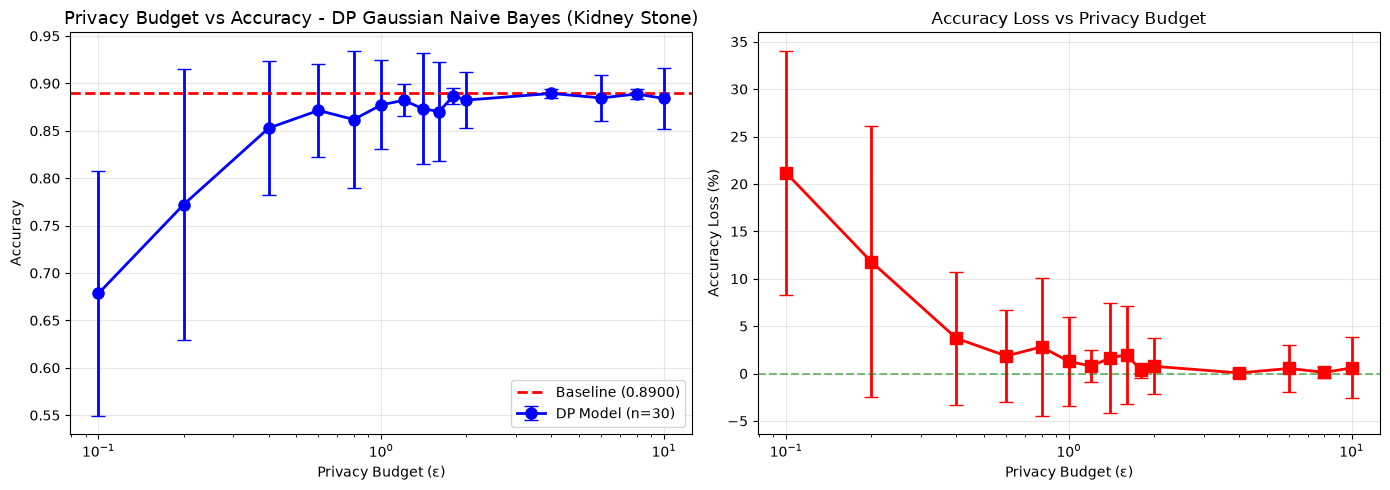

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].errorbar(results_df["epsilon"],results_df["accuracy_mean"],yerr=results_df["accuracy_std"],fmt="bo-",linewidth=2,markersize=8,capsize=5,label=f"DP Model (n={N_RUNS})")
if baseline_accuracy: axes[0].axhline(y=baseline_accuracy,color="r",linestyle="--",linewidth=2,label=f"Baseline ({baseline_accuracy:.4f})")
axes[0].set_title("Privacy Budget vs Accuracy - DP Gaussian Naive Bayes (Kidney Stone)",fontsize=13)
axes[0].set_xlabel("Privacy Budget (\u03b5)"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True,alpha=0.3); axes[0].set_xscale("log")
if baseline_accuracy:
    axes[1].errorbar(results_df["epsilon"],results_df["accuracy_loss_pct"],yerr=results_df["accuracy_std"]*100,fmt="rs-",linewidth=2,markersize=8,capsize=5)
    axes[1].set_title("Accuracy Loss vs Privacy Budget"); axes[1].set_xlabel("Privacy Budget (\u03b5)"); axes[1].set_ylabel("Accuracy Loss (%)")
    axes[1].grid(True,alpha=0.3); axes[1].set_xscale("log"); axes[1].axhline(y=0,color="g",linestyle="--",alpha=0.5)
plt.tight_layout(); plt.savefig("output/privacy_accuracy_tradeoff.png",dpi=150,bbox_inches="tight")
plt.show(); print("Plot saved.")
